# cir2c — RQ2 / RQ3 analysis

Parsing of the BenchExec result files under `../results/results/normalized/`.

## The four task sets (configs)

Suite names are **discovered from the result files**, not hardcoded, so the notebook
survives renames and extra suites (the next cell prints the actual names; the cell after
prints the per-suite task counts). There is one original C++ suite and three mapped-C
suites that differ in how the C++ standard library is handled by cir2c:

- **`cpp-baseline`** — the original C++ tasks, run only by the natively-C++ verifiers.
  Filtered to tasks that actually contain an assertion: the property is assertion failure
  (`reach_error` reachability), so a task with no assert is meaningless for it — and those
  assert-free tasks were also the main source of mislabeling, so they were dropped.
- **`c-exact_std`** — cir2c output with the std library mapped *accurately* (no
  over-approximation). May still contain unlinked `extern` functions, i.e. some function
  definitions are missing.
- **`c-nohavoc_std`** — same as `c-exact_std`, but the tasks that still have undefined
  `extern` functions are filtered out (so every called function has a definition).
- **`c-havoc_std`** — std library functions (and other unmodelled calls) are *havoc'd*:
  they may return anything. This is an over-approximation, which shows up in the results
  (e.g. spurious property violations / wrong verdicts).

By task name the sets nest: `c-nohavoc_std` ⊆ `c-exact_std` ⊆ `c-havoc_std` ⊆
`cpp-baseline`. The havoc set is the largest mapped set because havoc'ing lets cir2c map
tasks that an accurate std mapping cannot; `c-exact_std` then drops those, and
`c-nohavoc_std` drops the ones with leftover externs. Exact overlaps are reported by the
shared-task / dual-majority cells below.

## Tools per config

- **Every verifier** runs the mapped-C suites.
- **Only the natively-C++-capable verifiers** (`NATIVE_CPP_TOOLS` below: `esbmc-kind`,
  `cbmc`, `divine`) additionally run `cpp-baseline`. `cbmc` is then **excluded as a
  native-C++ verifier** (`CPP_EXCLUDE`; it solves only a small fragment of the C++ suite)
  so it does not skew the C++ consensus, but it stays an ordinary mapped-C verifier.
- Verifiers that never return a single true/false verdict are dropped right after
  parsing; the drop cell prints which ones and how many verifiers remain on each role.

The full tool list, suite list, and all counts are printed by the cells below — refer to
those for the current numbers.

In [43]:
import bz2
import re
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import pandas as pd

RESULTS_DIR = Path("../results/results/normalized")

# Verifiers that natively handle C++ and so also ran the original (un-mapped) suite.
# This is the one fixed fact. Suite/config names are *discovered* from the result
# files (next cell), so renamed suites or additional mapped suites need no edits here.
NATIVE_CPP_TOOLS = ["esbmc-kind", "cbmc", "divine"]

# Verifiers excluded *as native-C++ verifiers only* (their rows on the C++ suite are
# dropped): they solve only a fragment of the C++ suite and would skew its consensus.
# They are kept as ordinary mapped-C verifiers.
CPP_EXCLUDE = ["cbmc"]

# <tool>.<YYYY-MM-DD_HH-MM-SS>.results.<config>.<config>.xml.bz2
FNAME_RE = re.compile(
    r"^(?P<tool>.+?)\.(?P<date>\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})\.results\.(?P<config>[^.]+)\."
)

In [44]:
def _seconds(v):
    """'0.123s' -> 0.123 ; None/garbage -> NaN."""
    if not v:
        return np.nan
    v = v.strip().rstrip("s")
    try:
        return float(v)
    except ValueError:
        return np.nan


def _bytes(v):
    """'5607424B' -> 5607424.0 ; None/garbage -> NaN."""
    if not v:
        return np.nan
    v = v.strip().rstrip("B")
    try:
        return float(v)
    except ValueError:
        return np.nan


def _verdict(status):
    """Collapse a raw BenchExec status to true / false / unknown."""
    s = (status or "").lower()
    if s.startswith("true"):
        return "true"
    if s.startswith("false"):
        return "false"
    return "unknown"  # timeout, out of memory, any ERROR/EXCEPTION, plain 'unknown'


def parse_file(path: Path) -> list[dict]:
    m = FNAME_RE.match(path.name)
    tool, config = m["tool"], m["config"]
    root = ET.fromstring(bz2.open(path).read())
    out = []
    for run in root.findall("run"):
        cols = {c.get("title"): c.get("value") for c in run.findall("column")}
        name = run.get("name")
        out.append(
            {
                "tool": tool,
                "config": config,
                "task": name,                       # joins across suites (normalized)
                "group": name.split("/", 1)[0],     # algorithm / cbmc / ... (SV-COMP-style group)
                "expected": run.get("expectedVerdict"),   # ground-truth label: true / false
                "status": cols.get("status"),             # raw verifier status
                "bx_category": cols.get("category"),       # BenchExec: correct/wrong/unknown/error
                "verdict": _verdict(cols.get("status")),   # true / false / unknown
                "cputime": _seconds(cols.get("cputime")),  # seconds
                "walltime": _seconds(cols.get("walltime")),  # seconds
                "memory": _bytes(cols.get("memory")),      # bytes
                "termination": cols.get("terminationreason"),
            }
        )
    return out


df = pd.DataFrame(
    [row for f in sorted(RESULTS_DIR.glob("*.xml.bz2")) for row in parse_file(f)]
)

# --- Discover suites from the data (robust to renames and to extra mapped suites) ---
# A "mapped" suite is any C suite run by more verifiers than just the native-C++ trio;
# the original C++ suite(s) are run only by those. No suite name is hardcoded.
tools_per_config = df.groupby("config").tool.nunique()
MAPPED_CONFIGS = sorted(tools_per_config.index[tools_per_config > len(NATIVE_CPP_TOOLS)])
ORIGINAL_CONFIGS = sorted(c for c in tools_per_config.index if c not in MAPPED_CONFIGS)
CONFIGS = ORIGINAL_CONFIGS + MAPPED_CONFIGS  # display order: originals first

df["config"] = pd.Categorical(df["config"], CONFIGS, ordered=True)
# Correctness of the verdict vs. the suite label: True / False / NaN(=inconclusive).
df["correct"] = df["bx_category"].map({"correct": True, "wrong": False})

print(f"{len(df):,} rows | {df.tool.nunique()} tools")
print(f"  mapped suites:   {MAPPED_CONFIGS}")
print(f"  original suites: {ORIGINAL_CONFIGS}")
df.head()


66,279 rows | 29 tools
  mapped suites:   ['c-exact_std', 'c-havoc_std', 'c-nohavoc_std']
  original suites: ['cpp-baseline']


,tool,config,task,group,expected,status,bx_category,verdict,cputime,walltime,memory,termination,correct
0,2ls,c-exact_std,algorithm/algorithm1/algorithm_algorithm1.yml,algorithm,true,unknown,unknown,unknown,0.186541,4.917562,10088448.0,None,NaN
1,2ls,c-exact_std,algorithm/algorithm10/algorithm_algorithm10.yml,algorithm,true,unknown,unknown,unknown,0.134452,2.754136,7024640.0,None,NaN
2,2ls,c-exact_std,algorithm/algorithm101/algorithm_algorithm101.yml,algorithm,false,unknown,unknown,unknown,0.178262,2.759124,10526720.0,None,NaN
3,2ls,c-exact_std,algorithm/algorithm101_partial_sort/algorithm_...,algorithm,false,unknown,unknown,unknown,0.202985,2.685000,13320192.0,None,NaN
4,2ls,c-exact_std,algorithm/algorithm102/algorithm_algorithm102.yml,algorithm,false,unknown,unknown,unknown,0.259182,1.571239,9191424.0,None,NaN


In [45]:
# Drop C verifiers that never produced a single true/false verdict (only unknown) —
# they contribute nothing to verdict agreement. Done right after parsing so every
# downstream cell sees only the conclusive verifiers.
conclusive_tools = df.loc[df.verdict.isin(["true", "false"]), "tool"].unique()
dropped_tools = sorted(set(df.tool) - set(conclusive_tools))
df = df[df.tool.isin(conclusive_tools)].copy()
print(f"Dropped {len(dropped_tools)} unknown-only verifiers: {dropped_tools}")

# Drop CPP_EXCLUDE verifiers from the original C++ suite(s) only (they remain on the
# mapped-C suites). ORIGINAL_CONFIGS comes from the discovery in the previous cell.
df = df[~(df.tool.isin(CPP_EXCLUDE) & df.config.isin(ORIGINAL_CONFIGS))].copy()
print(f"Excluded {CPP_EXCLUDE} from C++ suite(s) {ORIGINAL_CONFIGS}")

print(f"Remaining verifiers: {df[df.config.isin(ORIGINAL_CONFIGS)].tool.nunique()} on C++, "
      f"{df[df.config.isin(MAPPED_CONFIGS)].tool.nunique()} on mapped-C")


Dropped 10 unknown-only verifiers: ['cpv', 'crux', 'goblint', 'goblint-par', 'goblitch', 'graves', 'infer', 're3ver', 'symbiotic', 'veriabsl']
Excluded ['cbmc'] from C++ suite(s) ['cpp-baseline']
Remaining verifiers: 2 on C++, 19 on mapped-C


In [46]:
# Which tool ran which suite, and on how many tasks (blank = not run).
runs = df.pivot_table(
    index="tool", columns="config", values="task", aggfunc="count", observed=False
)
display(runs)

# Per-suite outcome breakdown (verdict vs. suite label).
summary = (
    df.groupby("config", observed=True)
    .agg(
        runs=("task", "count"),
        correct=("correct", lambda s: int((s == True).sum())),
        wrong=("correct", lambda s: int((s == False).sum())),
        inconclusive=("verdict", lambda s: int((s == "unknown").sum())),
        said_true=("verdict", lambda s: int((s == "true").sum())),
        said_false=("verdict", lambda s: int((s == "false").sum())),
    )
)
display(summary)


config,cpp-baseline,c-exact_std,c-havoc_std,c-nohavoc_std
tool,,,,
2ls,0,983,1011,178
bubaak,0,983,1011,178
bubaak-split,0,983,1011,178
cbmc,0,983,1011,178
cpachecker,0,983,1011,178
divine,1097,983,1011,178
emergentheta,0,983,1011,178
esbmc-kind,1097,983,1011,178
mopsa,0,983,1011,178


,runs,correct,wrong,inconclusive,said_true,said_false
config,,,,,,
cpp-baseline,2194,1465,98,631,1110,453
c-exact_std,18677,3246,809,14622,2199,1856
c-havoc_std,19209,4450,2905,11854,1820,5535
c-nohavoc_std,3382,1803,177,1402,1357,623


## Sanity check: answers returned on the mapped (C) suites

Every distinct BenchExec `category` and raw verifier `status` produced by the C
verifiers, and how each status collapses into our `true` / `false` / `unknown`.


In [47]:
# Restrict to the mapped (C) suites — these are what the C verifiers actually consume.
mapped = df[df.config.isin(MAPPED_CONFIGS)]

print("BenchExec categories:", sorted(mapped.bx_category.dropna().unique()))
print(f"Distinct raw statuses: {mapped.status.nunique()}\n")

status_tbl = (
    mapped.groupby("status")
    .agg(verdict=("verdict", "first"), n=("task", "size"))
    .sort_values("n", ascending=False)
)
status_tbl


BenchExec categories: ['correct', 'error', 'unknown', 'wrong']
Distinct raw statuses: 22



,verdict,n
status,,
unknown,unknown,10420
false(unreach-call),false,8014
true,true,5376
"ERROR (frontend failed, before parsing finished)",unknown,4134
TIMEOUT,unknown,2887
ERROR (6),unknown,2169
ERROR (134),unknown,2169
ERROR (1),unknown,1578
ERROR,unknown,1476


In [48]:
import matplotlib.pyplot as plt

# Export targets: figures/<rq>/ holds <name>.pdf (plots) and <name>.tex (a figure or
# table environment that \input-s into the paper).
#
# FIG_ROOT is where this notebook writes artifacts. PAPER_FIG_DIR is the prefix baked into
# the \includegraphics paths inside the generated .tex: in the paper the figures live under
# <paper>/figures/results/rq23/<rq>/ (this figures/ folder is copied there), and the prefix
# is relative to the main paper .tex. So a generated figure .tex can be \input directly.
FIG_ROOT = Path("figures")              # where this notebook writes the .pdf/.tex artifacts
PAPER_FIG_DIR = "figures/results/rq23"  # \includegraphics prefix, relative to the paper's main .tex
for _rq in ("rq2", "rq3"):
    (FIG_ROOT / _rq).mkdir(parents=True, exist_ok=True)

# Every export appends here so figures/README.md can be regenerated from the exact set of
# artifacts this run produced (see the manifest cell at the end). Reset on each run of this
# cell so a top-to-bottom execution starts clean.
MANIFEST = []


def export_fig(fig, rq, name, caption, label=None, width=r"\linewidth"):
    """Save fig as figures/<rq>/<name>.pdf + a sibling .tex figure environment, show it."""
    label = label or "fig:" + name.replace("_", "-")
    fig.savefig(FIG_ROOT / rq / f"{name}.pdf", bbox_inches="tight")
    (FIG_ROOT / rq / f"{name}.tex").write_text(
        "\\begin{figure}[t]\n  \\centering\n"
        f"  \\includegraphics[width={width}]{{{PAPER_FIG_DIR}/{rq}/{name}.pdf}}\n"
        f"  \\caption{{{caption}}}\n  \\label{{{label}}}\n"
        "\\end{figure}\n",
        encoding="utf-8",
    )
    MANIFEST.append(dict(rq=rq, name=name, kind="figure", label=label, caption=caption))
    display(fig)
    plt.close(fig)


def export_table(frame, rq, name, caption, label=None, **to_latex_kw):
    """Write a LaTeX table environment wrapping frame.to_latex to figures/<rq>/<name>.tex."""
    label = label or "tab:" + name.replace("_", "-")
    opts = dict(index=True, escape=True, float_format="%.4g")
    opts.update(to_latex_kw)
    (FIG_ROOT / rq / f"{name}.tex").write_text(
        "\\begin{table}[t]\n  \\centering\n"
        f"  \\caption{{{caption}}}\n  \\label{{{label}}}\n"
        f"{frame.to_latex(**opts)}"
        "\\end{table}\n",
        encoding="utf-8",
    )
    MANIFEST.append(dict(rq=rq, name=name, kind="table", label=label, caption=caption))
    return frame  # so callers can `display(export_table(...))`

## Verifier agreement per task

For each task we collapse the answers of the retained C verifiers into a triple
`(#true, #false, #unknown)` (the three sum to the number of retained verifiers). We
then count, **per mapped suite and per ground-truth label**, how many tasks share each
triple — i.e. how many tasks the verifiers (dis)agreed on in the same way.

`label` is the suite's ground-truth `expected_verdict`; `n_tasks` is how many tasks
fall into that exact agreement pattern.


In [49]:
def agreement_table(cfg: str) -> pd.DataFrame:
    """Per task: (#true,#false,#unknown) over the C verifiers, then count tasks per
    (label, triple). One row per distinct agreement pattern."""
    sub = df[df.config == cfg]
    per_task = (
        sub.pivot_table(index=["task", "expected"], columns="verdict",
                        values="tool", aggfunc="count", fill_value=0)
        .reindex(columns=["true", "false", "unknown"], fill_value=0)
        .reset_index()
        .rename(columns={"expected": "label"})
    )
    return (
        per_task.groupby(["label", "true", "false", "unknown"])
        .size().reset_index(name="n_tasks")
        .sort_values(["label", "n_tasks"], ascending=[True, False])
        .reset_index(drop=True)
    )


agreement = {cfg: agreement_table(cfg) for cfg in MAPPED_CONFIGS}
for cfg, tbl in agreement.items():
    print(f"\n===== {cfg}: {tbl.n_tasks.sum()} tasks, "
          f"{len(tbl)} distinct (true,false,unknown) patterns =====")
    display(tbl)



===== c-exact_std: 983 tasks, 88 distinct (true,false,unknown) patterns =====


,label,true,false,unknown,n_tasks
0,false,0,3,16,69
1,false,0,2,17,66
2,false,1,2,16,64
3,false,0,4,15,48
4,false,1,0,18,37
...,...,...,...,...,...
83,true,10,1,8,1
84,true,11,2,6,1
85,true,13,0,6,1
86,true,13,1,5,1



===== c-havoc_std: 1011 tasks, 87 distinct (true,false,unknown) patterns =====


,label,true,false,unknown,n_tasks
0,false,0,7,12,80
1,false,1,8,10,49
2,false,0,6,13,46
3,false,0,8,11,35
4,false,2,7,10,31
...,...,...,...,...,...
82,true,7,0,12,1
83,true,10,1,8,1
84,true,11,2,6,1
85,true,13,1,5,1



===== c-nohavoc_std: 178 tasks, 51 distinct (true,false,unknown) patterns =====


,label,true,false,unknown,n_tasks
0,false,0,9,10,9
1,false,0,10,9,8
2,false,0,11,8,8
3,false,0,8,11,6
4,false,2,9,8,5
5,false,0,13,6,4
6,false,0,6,13,3
7,false,0,7,12,3
8,false,0,12,7,3
9,false,2,10,7,2


## Collapsed agreement views

Two coarser per-task labels derived from the verifier votes, to weigh against the full
per-pattern breakdown above:

- **majority** — true vs false only (unknowns ignored): `true`/`false` if it has strictly
  more votes, `tie` if equal but nonzero, `unknown` only when no verifier decided at all.
- **unanimous** — among verifiers that gave *any* verdict: `all-true` / `all-false` /
  `conflict` (both true and false seen) / `none` (no verdict at all).

Rows are the ground-truth `label`; cells count tasks.

In [50]:
def per_task_counts(cfg: str) -> pd.DataFrame:
    """One row per task: columns label, true, false, unknown (vote counts)."""
    return (
        df[df.config == cfg]
        .pivot_table(index=["task", "expected"], columns="verdict",
                     values="tool", aggfunc="count", fill_value=0)
        .reindex(columns=["true", "false", "unknown"], fill_value=0)
        .reset_index()
        .rename(columns={"expected": "label"})
    )


def collapse(pt: pd.DataFrame) -> pd.DataFrame:
    """Add `majority` and `unanimous` per-task labels to a per_task_counts frame."""
    pt = pt.copy()
    # Majority is decided on true vs false only (unknowns ignored): `unknown` only
    # when no verifier gave any verdict, `tie` when true and false votes are equal
    # but nonzero.
    pt["majority"] = np.select(
        [(pt.true == 0) & (pt.false == 0), pt.true > pt.false, pt.false > pt.true],
        ["unknown", "true", "false"],
        default="tie",
    )
    pt["unanimous"] = np.select(
        [(pt.true > 0) & (pt.false > 0), pt.true > 0, pt.false > 0],
        ["conflict", "all-true", "all-false"],
        default="none",
    )
    return pt


for cfg in MAPPED_CONFIGS:
    pt = collapse(per_task_counts(cfg))
    print(f"\n===== {cfg} ({len(pt)} tasks) =====")
    maj = pd.crosstab(pt.label, pt.majority).rename_axis(columns="majority")
    una = pd.crosstab(pt.label, pt.unanimous).rename_axis(columns="unanimous")
    display(export_table(maj, "rq2", f"majority_{cfg}",
                         f"Per-task majority verdict vs.\\ ground-truth label on "
                         f"\\texttt{{{cfg}}} (true vs.\\ false; unknowns ignored).",
                         label=f"tab:majority-{cfg}"))
    display(export_table(una, "rq2", f"unanimous_{cfg}",
                         f"Per-task unanimity among deciding verifiers vs.\\ ground-truth "
                         f"label on \\texttt{{{cfg}}}.",
                         label=f"tab:unanimous-{cfg}"))



===== c-exact_std (983 tasks) =====


majority,false,tie,true,unknown
label,,,,
false,341,16,81,14
true,126,15,353,37


unanimous,all-false,all-true,conflict,none
label,,,,
false,252,74,112,14
true,114,315,65,37



===== c-havoc_std (1011 tasks) =====


majority,false,tie,true,unknown
label,,,,
false,456,2,8,0
true,427,0,117,1


unanimous,all-false,all-true,conflict,none
label,,,,
false,297,3,166,0
true,304,86,154,1



===== c-nohavoc_std (178 tasks) =====


majority,false,true,unknown
label,,,
false,53,4,0
true,9,111,1


unanimous,all-false,all-true,conflict,none
label,,,,
false,44,1,12,0
true,4,82,34,1


## Majority strength: how overwhelming is the consensus

For every task with a strict majority (`majority` in {`true`, `false`}; ties and
all-unknown excluded), count the verifiers voting **against** the majority — `false`
votes when the majority is `true` and vice versa, ignoring unknowns. This is the
dissent, and it measures how lopsided each majority is. The table reports, per mapped
suite, the dissent's min / median / mean / max, the share of strict majorities that are
unanimous (zero dissent), and the mean dissent as a percentage of the deciding verifiers
(`deciders = #true + #false`, which varies per task because of unknowns). The inline
splits break the same dissent down by majority direction and by whether the majority is
correct. The original C++ suites are omitted: with 2 verifiers a strict majority is
always 2–0, so dissent is trivially 0.


In [51]:
# Per strict-majority task, how lopsided is the consensus: count the verifiers voting
# *against* the majority (false votes when the majority is true, and vice versa; unknowns
# ignored). Only the mapped-C suites are meaningful here — the C++ suites have 2 verifiers,
# so a strict majority is always 2-0 and dissent is trivially 0.
def majority_strength(cfg: str) -> pd.DataFrame:
    """One row per strict-majority task: deciders and votes for/against the majority."""
    pt = collapse(per_task_counts(cfg))
    pt = pt[pt.majority.isin(["true", "false"])].copy()
    pt["deciders"] = pt.true + pt.false                  # verifiers that gave any verdict
    pt["against"] = np.minimum(pt.true, pt.false)        # votes opposing the majority
    pt["against_share"] = pt["against"] / pt.deciders    # dissent as a fraction of deciders
    pt["maj_correct"] = pt.majority == pt.label          # does the majority match ground truth
    return pt


def strength_stats(pt: pd.DataFrame) -> pd.Series:
    a = pt["against"]
    return pd.Series({
        "tasks": len(pt),
        "deciders_med": pt.deciders.median(),
        "against_min": int(a.min()),
        "against_med": a.median(),
        "against_mean": a.mean(),
        "against_max": int(a.max()),
        "unanimous_pct": 100 * (a == 0).mean(),          # share of tasks with zero dissent
        "share_mean": 100 * pt.against_share.mean(),     # mean dissent / deciders, %
    })


strength = pd.DataFrame({cfg: strength_stats(majority_strength(cfg))
                         for cfg in MAPPED_CONFIGS}).T
display(export_table(strength, "rq2", "majority_strength",
        "How lopsided the per-task majority is on the mapped-C suites: over tasks with a "
        "strict majority, the number of verifiers voting against it (\\emph{against\\_*}; "
        "unknowns ignored), with the median number of deciding verifiers for context. "
        "\\emph{unanimous\\_pct} is the share of those tasks with zero dissent; "
        "\\emph{share\\_mean} is the mean dissent as a percentage of deciding verifiers.",
        label="tab:majority-strength"))

# Same dissent stats split by majority direction and by majority correctness (inline only).
for cfg in MAPPED_CONFIGS:
    pt = majority_strength(cfg)
    print(f"\n===== {cfg}: verifiers against the majority =====")
    print("by majority verdict:")
    display(pt.groupby("majority").against.agg(["count", "min", "median", "mean", "max"]))
    print("by majority correctness (matches ground-truth label):")
    display(pt.groupby("maj_correct").against.agg(["count", "min", "median", "mean", "max"]))


,tasks,deciders_med,against_min,against_med,against_mean,against_max,unanimous_pct,share_mean
c-exact_std,901.0,3.0,0.0,0.0,0.201998,4.0,83.795782,4.376063
c-havoc_std,1008.0,7.0,0.0,0.0,0.485119,4.0,68.452381,6.461344
c-nohavoc_std,177.0,12.0,0.0,0.0,0.446328,4.0,74.011299,4.695852



===== c-exact_std: verifiers against the majority =====
by majority verdict:


,count,min,median,mean,max
majority,,,,,
false,467,0,0.0,0.248394,4
true,434,0,0.0,0.152074,4


by majority correctness (matches ground-truth label):


,count,min,median,mean,max
maj_correct,,,,,
False,207,0,0.0,0.115942,4
True,694,0,0.0,0.227666,4


...

,count,min,median,mean,max
maj_correct,,,,,
False,435,0,0.0,0.531034,4
True,573,0,0.0,0.450262,4



===== c-nohavoc_std: verifiers against the majority =====
by majority verdict:


,count,min,median,mean,max
majority,,,,,
false,62,0,0.0,0.419355,4
true,115,0,0.0,0.460870,4


by majority correctness (matches ground-truth label):


,count,min,median,mean,max
maj_correct,,,,,
False,13,0,1.0,0.923077,4
True,164,0,0.0,0.408537,4


## Pattern distribution (stacked bar chart)

One bar per distinct agreement pattern, faceted by ground-truth `label`. Each bar is
stacked by the verdict mix `(#true / #false / #unknown)` — so every bar is as tall as the
number of retained verifiers (printed in the drop cell above) and you read off the
*proportions*. The x-axis label under each bar is `n_tasks`: how many tasks had that exact
distribution. Bars are sorted by `n_tasks`, so the left-most, most-common patterns are the
ones worth collapsing around.

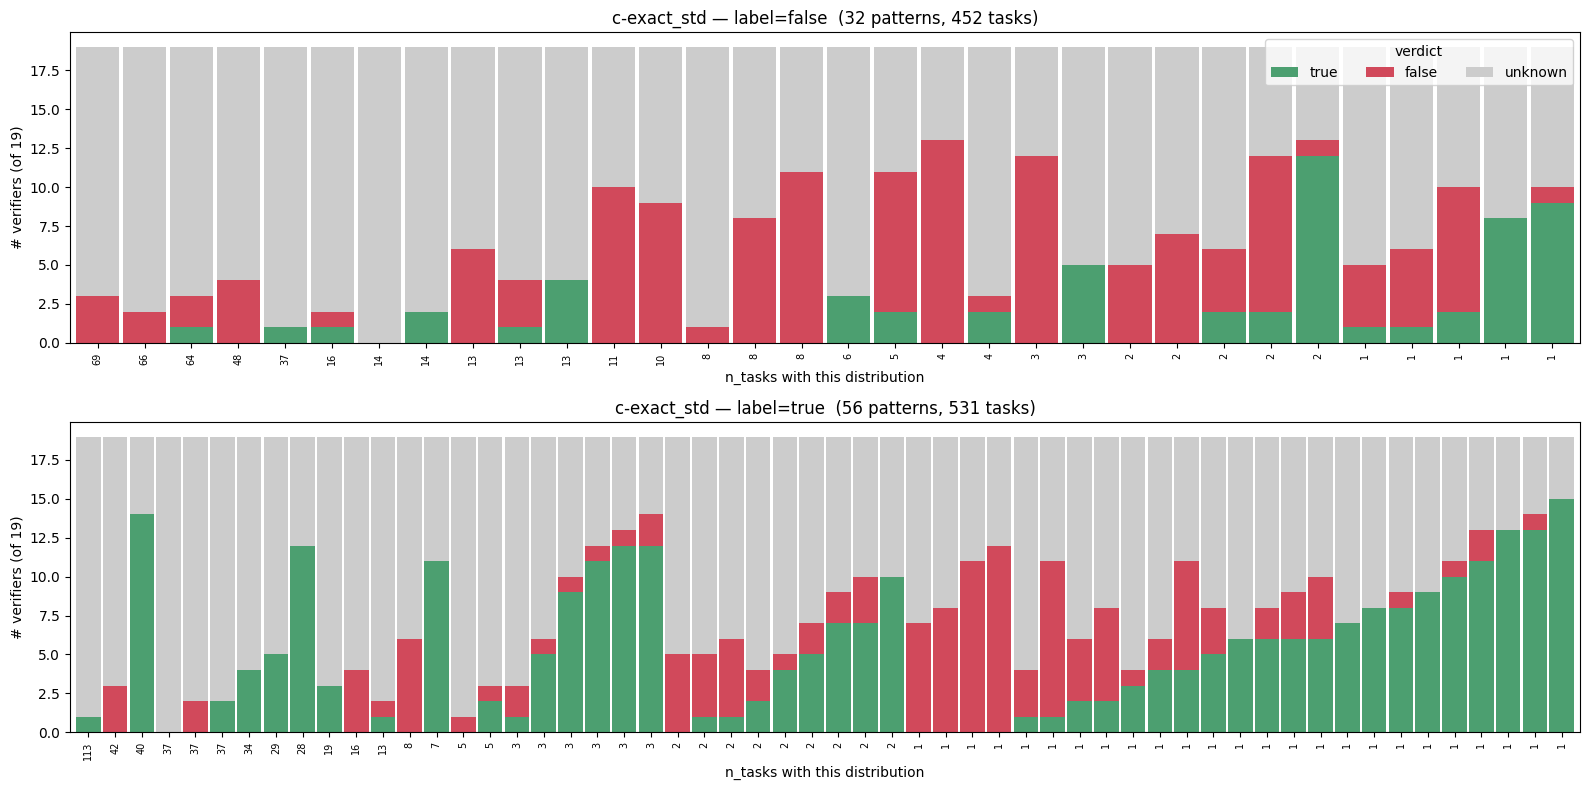

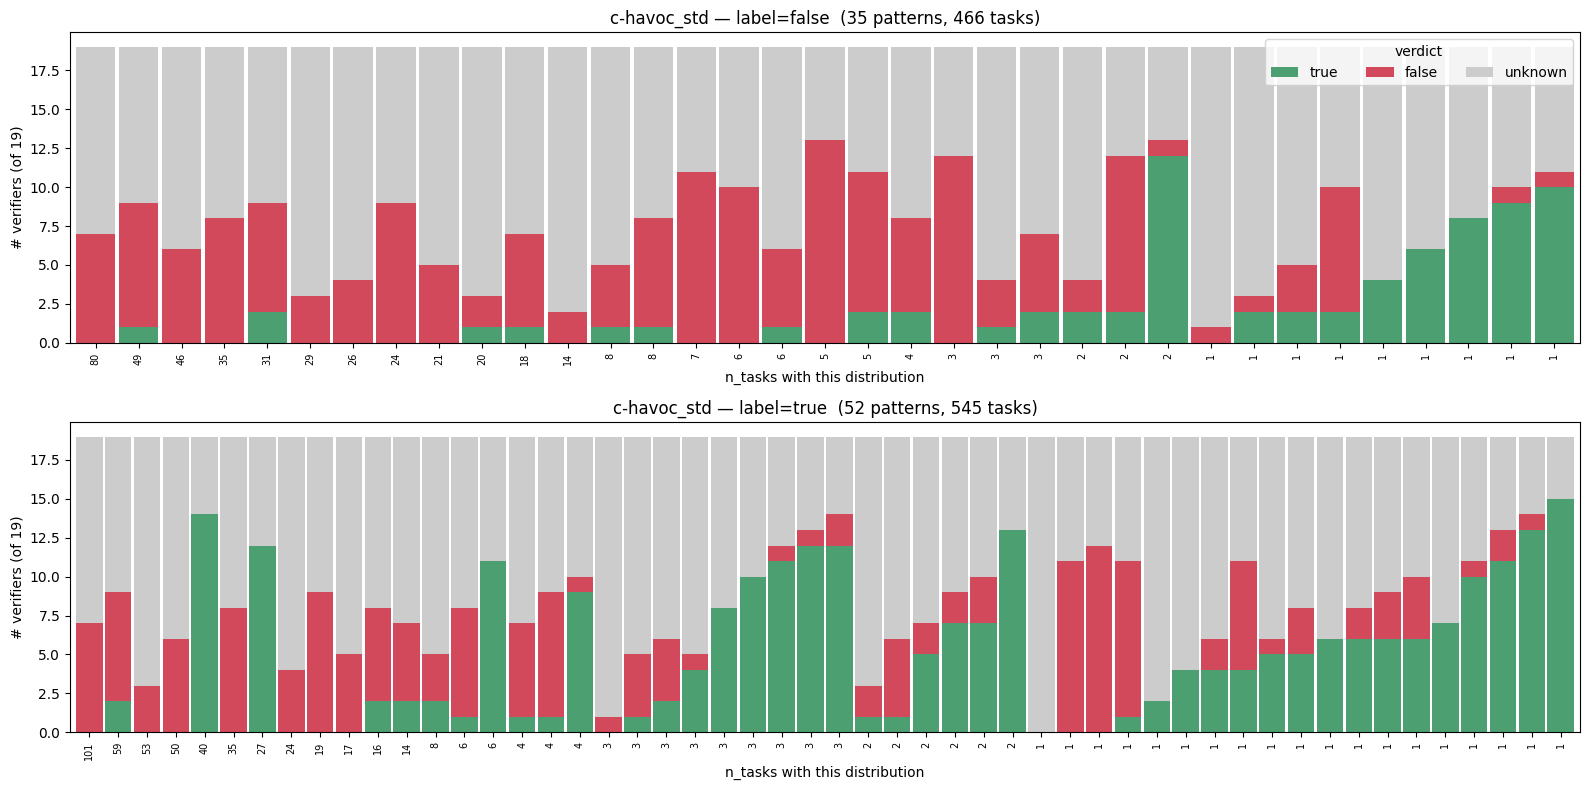

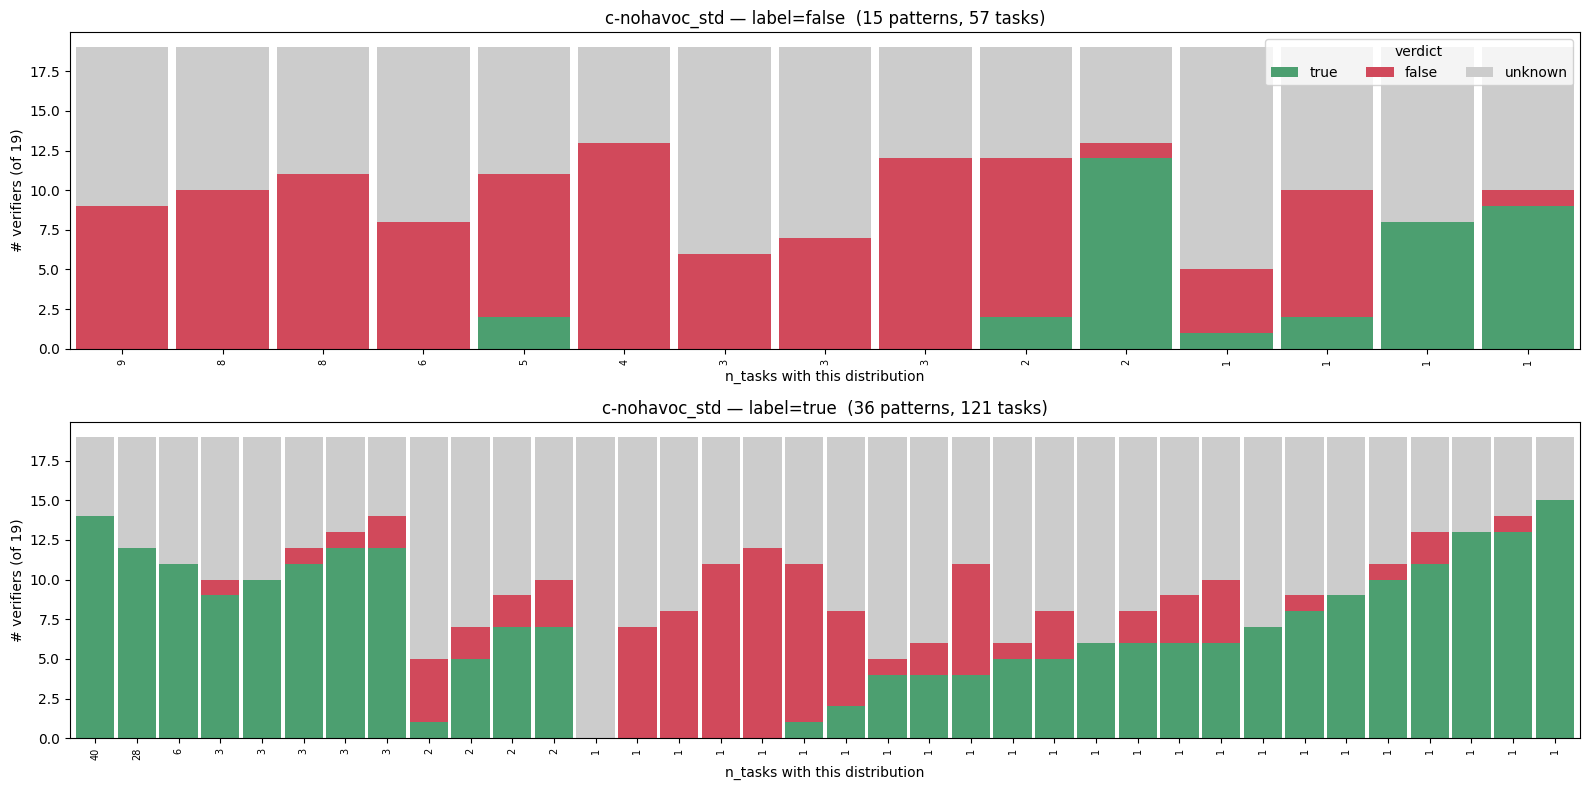

In [52]:
VCOLORS = {"true": "#4C9F70", "false": "#D1495B", "unknown": "#CCCCCC"}


def plot_patterns(cfg: str, tbl: pd.DataFrame | None = None):
    tbl = agreement[cfg] if tbl is None else tbl   # (label, true, false, unknown, n_tasks)
    n_ver = int(tbl[["true", "false", "unknown"]].sum(axis=1).max())  # verifiers per task
    labels = list(tbl.label.unique())
    fig, axes = plt.subplots(len(labels), 1, figsize=(16, 4 * len(labels)), squeeze=False)
    for ax, lab in zip(axes[:, 0], labels):
        d = (tbl[tbl.label == lab]
             .sort_values("n_tasks", ascending=False).reset_index(drop=True))
        x = range(len(d))
        bottom = np.zeros(len(d))
        for v in ("true", "false", "unknown"):
            ax.bar(x, d[v], bottom=bottom, width=0.92, color=VCOLORS[v], label=v)
            bottom += d[v].to_numpy()
        ax.set_xticks(list(x))
        ax.set_xticklabels(d.n_tasks, rotation=90, fontsize=7)
        ax.set_xlabel("n_tasks with this distribution")
        ax.set_ylabel(f"# verifiers (of {n_ver})")
        ax.set_title(f"{cfg} — label={lab}  "
                     f"({len(d)} patterns, {d.n_tasks.sum()} tasks)")
        ax.margins(x=0.004)
    axes[0, 0].legend(title="verdict", ncol=3, loc="upper right")
    fig.tight_layout()
    return fig


for cfg in MAPPED_CONFIGS:
    export_fig(plot_patterns(cfg), "rq2", f"pattern_{cfg}",
               f"Distribution of verifier-agreement patterns on \\texttt{{{cfg}}}, "
               f"faceted by ground-truth label; bars sorted by task count.",
               label=f"fig:pattern-{cfg}")


## C++ comparison: the same views on the original suite

The same majority / unanimous tables and stacked-bar plot for the original C++ suite(s).
`cbmc` is excluded as a native-C++ verifier (it solves only a fragment of the suite),
leaving `divine` and `esbmc-kind` — so the votes here are out of 2, not out of the full
set of retained mapped-C verifiers.


===== cpp-baseline (1097 tasks, 2 verifiers) =====


majority,false,tie,true,unknown
label,,,,
false,411,9,52,47
true,12,21,540,5


unanimous,all-false,all-true,conflict,none
label,,,,
false,411,52,9,47
true,12,540,21,5


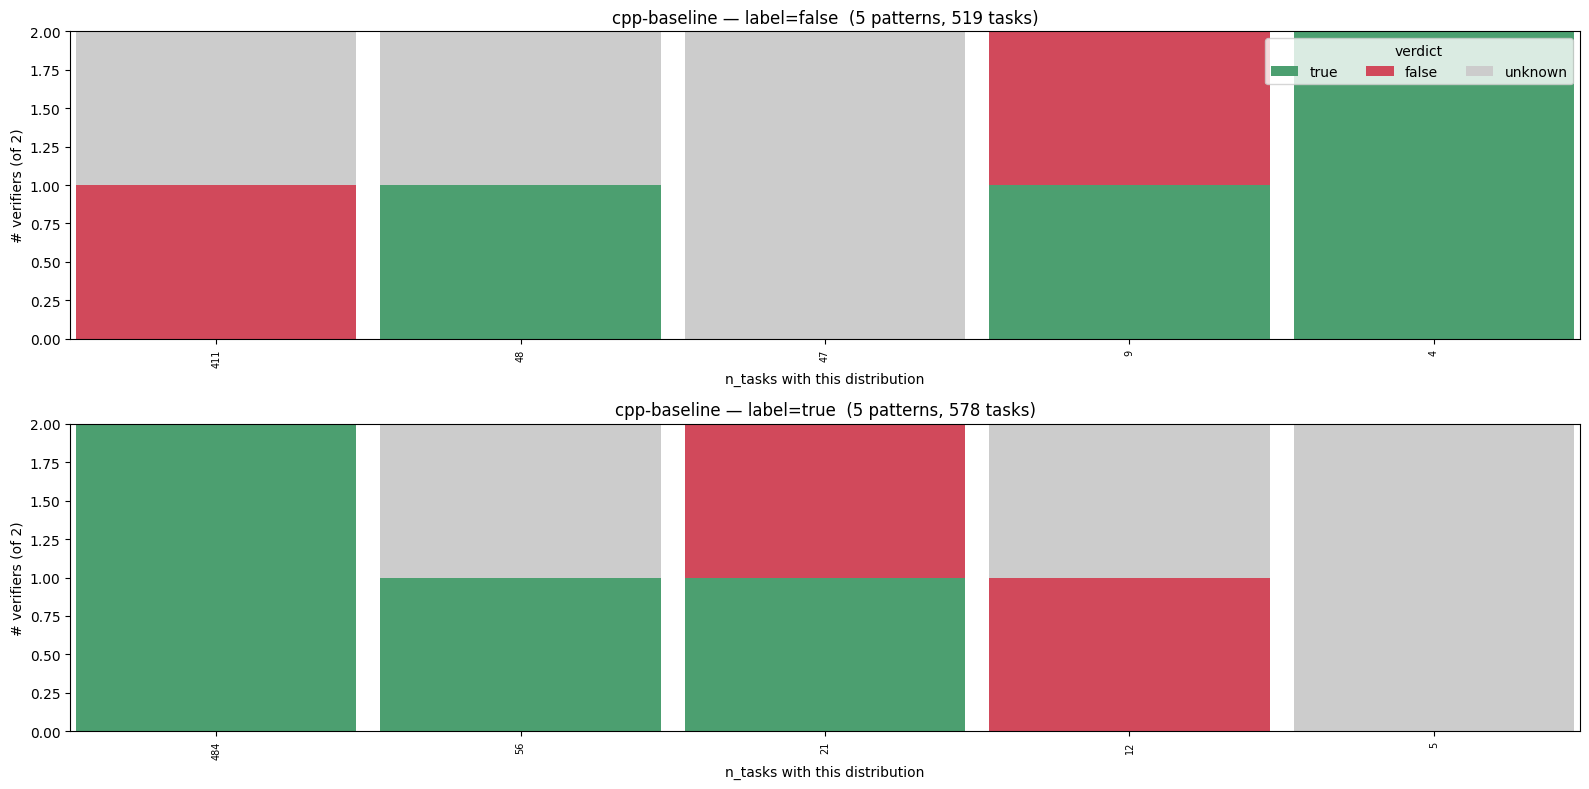

In [53]:
for cfg in ORIGINAL_CONFIGS:
    pt = collapse(per_task_counts(cfg))
    n_ver = df[df.config == cfg].tool.nunique()
    print(f"\n===== {cfg} ({len(pt)} tasks, {n_ver} verifiers) =====")
    maj = pd.crosstab(pt.label, pt.majority).rename_axis(columns="majority")
    una = pd.crosstab(pt.label, pt.unanimous).rename_axis(columns="unanimous")
    display(export_table(maj, "rq2", f"majority_{cfg}",
                         f"Per-task majority verdict vs.\\ ground-truth label on the "
                         f"original C++ suite \\texttt{{{cfg}}}.",
                         label=f"tab:majority-{cfg}"))
    display(export_table(una, "rq2", f"unanimous_{cfg}",
                         f"Per-task unanimity vs.\\ ground-truth label on the original "
                         f"C++ suite \\texttt{{{cfg}}}.",
                         label=f"tab:unanimous-{cfg}"))
    export_fig(plot_patterns(cfg, agreement_table(cfg)), "rq2", f"pattern_{cfg}",
               f"Distribution of verifier-agreement patterns on the original C++ suite "
               f"\\texttt{{{cfg}}}.",
               label=f"fig:pattern-{cfg}")


### C++ majority ties: who voted what

For every tie task on the original C++ suite, the per-verifier verdict (`divine` /
`esbmc-kind`; `cbmc` excluded).


In [54]:
for cfg in ORIGINAL_CONFIGS:
    pt = collapse(per_task_counts(cfg))
    tie_tasks = pt.loc[pt.majority == "tie", "task"]
    votes = (
        df[(df.config == cfg) & (df.task.isin(tie_tasks))]
        .pivot_table(index="task", columns="tool", values="verdict", aggfunc="first")
    )
    print(f"{cfg}: {len(tie_tasks)} tie tasks")
    display(votes)


cpp-baseline: 30 tie tasks


tool,divine,esbmc-kind
task,,
algorithm/algorithm57/algorithm_algorithm57.yml,true,false
algorithm/algorithm58/algorithm_algorithm58.yml,true,false
algorithm/algorithm69_adjacent_find1/algorithm_algorithm69_adjacent_find1.yml,true,false
algorithm/algorithm70/algorithm_algorithm70.yml,true,false
cbmc/Templates6/cbmc_Templates6.yml,true,false
deque/deque_erase/deque_deque_erase.yml,true,false
gcc-template-tests/ctor2/gcc-template-tests_ctor2.yml,true,false
inheritance_bringup/inheritance09/inheritance_bringup_inheritance09.yml,true,false
list/list_insert/list_list_insert.yml,true,false


## Dual majority: C++ vs C (mapped)

Join each mapped suite to the original C++ suite on the shared tasks, and cross the two
majority verdicts. The diagonal is agreement between the C++ and the mapped-C consensus;
off-diagonal cells are where mapping flipped (or lost) the consensus. The heatmap shows
how those `(C++ majority, C majority)` combinations are distributed. Next to it, the same
shared tasks are crossed against the ground-truth `label` instead of the C++ majority, i.e.
`(label, C majority)`, for a direct soundness read independent of the (only-2-verifier)
C++ consensus.


===== cpp-baseline (C++) vs c-exact_std: 983 shared tasks =====


<>:40: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<>:40: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
/tmp/ipykernel_8593/3703339848.py:40: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
  """Two heatmaps side by side: C++ majority vs.\ C majority, and label vs.\ C majority."""


c_majority,true,false,tie,unknown
cpp_majority,,,,
true,349,143,16,33
false,65,308,13,12
tie,14,10,2,3
unknown,6,6,0,3


c_majority,true,false,tie,unknown
label,,,,
true,353,126,15,37
false,81,341,16,14


c_majority          false  tie  true  unknown
label cpp_majority                           
false false           305   13    58       12
      tie               5    1     3        0
      true             27    2    14        1
      unknown           4    0     6        1
true  false             3    0     7        0
      tie               5    1    11        3
      true            116   14   335       32
      unknown           2    0     0        2

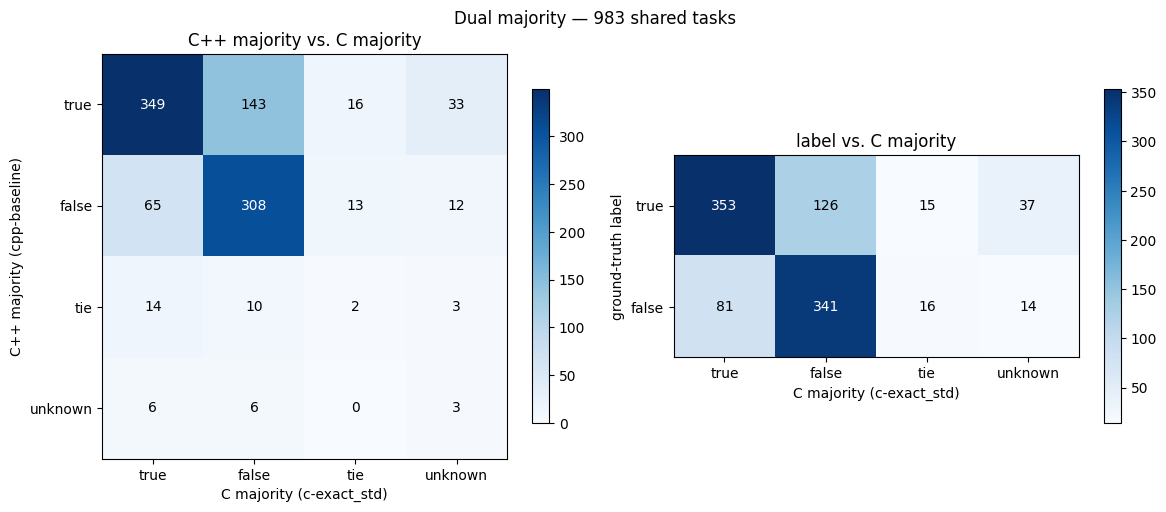


===== cpp-baseline (C++) vs c-havoc_std: 1011 shared tasks =====


c_majority,true,false,tie,unknown
cpp_majority,,,,
true,115,440,0,0
false,7,399,2,0
tie,3,27,0,0
unknown,0,17,0,1


c_majority,true,false,tie,unknown
label,,,,
true,117,427,0,1
false,8,456,2,0


c_majority          false  tie  true  unknown
label cpp_majority                           
false false           390    2     6        0
      tie               9    0     0        0
      true             43    0     2        0
      unknown          14    0     0        0
true  false             9    0     1        0
      tie              18    0     3        0
      true            397    0   113        0
      unknown           3    0     0        1

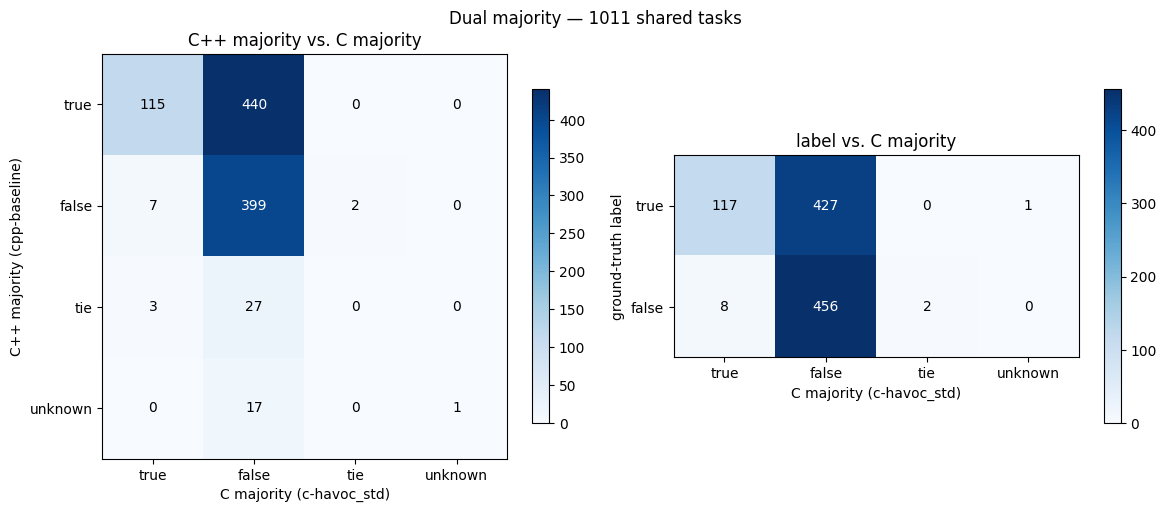


===== cpp-baseline (C++) vs c-nohavoc_std: 178 shared tasks =====


c_majority,true,false,tie,unknown
cpp_majority,,,,
true,109,6,0,0
false,3,52,0,0
tie,3,3,0,0
unknown,0,1,0,1


c_majority,true,false,tie,unknown
label,,,,
true,111,9,0,1
false,4,53,0,0


c_majority          false  true  unknown
label cpp_majority                      
false false            51     2        0
      true              1     2        0
      unknown           1     0        0
true  false             1     1        0
      tie               3     3        0
      true              5   107        0
      unknown           0     0        1

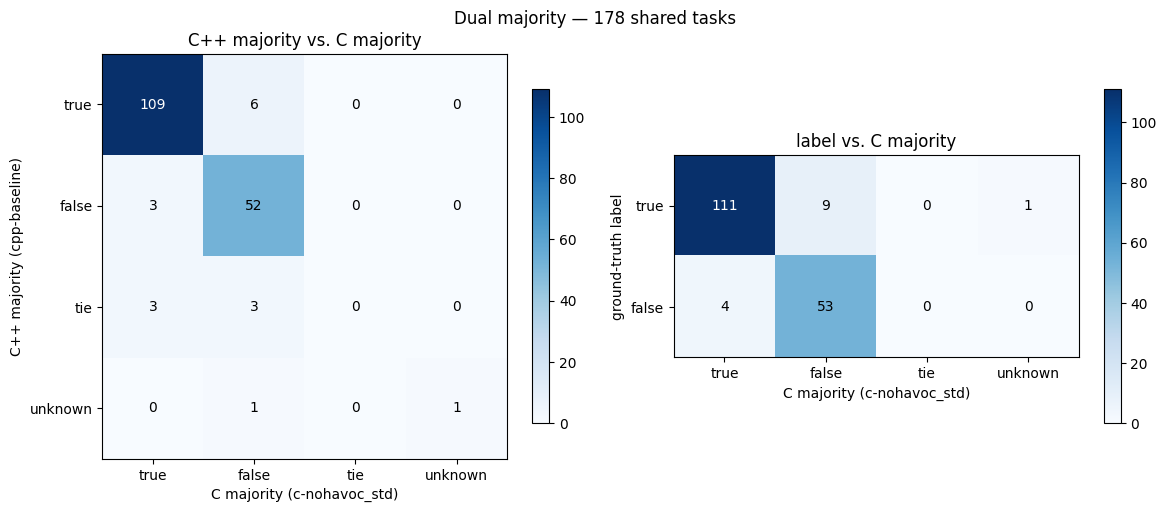

In [55]:
MAJ_ORDER = ["true", "false", "tie", "unknown"]
CPP_REF = ORIGINAL_CONFIGS[0]  # original C++ suite used as the reference


def dual_majority(c_cfg: str, cpp_cfg: str = CPP_REF) -> pd.DataFrame:
    """Per-task C++ vs mapped-C majority, joined on the shared tasks (and label)."""
    def m(cfg, col):
        return (collapse(per_task_counts(cfg))[["task", "label", "majority"]]
                .rename(columns={"majority": col}))
    return m(cpp_cfg, "cpp_majority").merge(m(c_cfg, "c_majority"), on=["task", "label"])


def dual_crosstab(dm: pd.DataFrame) -> pd.DataFrame:
    return (pd.crosstab(dm.cpp_majority, dm.c_majority)
            .reindex(index=MAJ_ORDER, columns=MAJ_ORDER, fill_value=0))


def label_crosstab(dm: pd.DataFrame) -> pd.DataFrame:
    """Ground-truth label vs. mapped-C majority, over the same shared tasks as dual_crosstab."""
    return (pd.crosstab(dm.label, dm.c_majority)
            .reindex(index=["true", "false"], columns=MAJ_ORDER, fill_value=0))


def _draw_heatmap(ax, ct: pd.DataFrame, ylabel: str, title: str):
    im = ax.imshow(ct.values, cmap="Blues")
    ax.set_xticks(range(len(MAJ_ORDER)), MAJ_ORDER)
    ax.set_yticks(range(len(ct.index)), ct.index)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    hi = ct.values.max() if ct.values.size else 0
    for i in range(len(ct.index)):
        for j in range(len(MAJ_ORDER)):
            v = ct.values[i, j]
            ax.text(j, i, int(v), ha="center", va="center",
                    color="white" if hi and v > hi / 2 else "black")
    return im


def plot_dual(ct_cpp: pd.DataFrame, ct_label: pd.DataFrame, c_cfg: str, n: int):
    """Two heatmaps side by side: C++ majority vs.\ C majority, and label vs.\ C majority."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    im0 = _draw_heatmap(axes[0], ct_cpp, f"C++ majority ({CPP_REF})", "C++ majority vs. C majority")
    im1 = _draw_heatmap(axes[1], ct_label, "ground-truth label", "label vs. C majority")
    for ax in axes:
        ax.set_xlabel(f"C majority ({c_cfg})")
    fig.colorbar(im0, ax=axes[0], shrink=0.8)
    fig.colorbar(im1, ax=axes[1], shrink=0.8)
    fig.suptitle(f"Dual majority — {n} shared tasks")
    fig.tight_layout()
    return fig


for c_cfg in MAPPED_CONFIGS:
    dm = dual_majority(c_cfg)
    ct = dual_crosstab(dm)
    ct_label = label_crosstab(dm)
    print(f"\n===== {CPP_REF} (C++) vs {c_cfg}: {len(dm)} shared tasks =====")
    display(export_table(ct, "rq2", f"dual_majority_{c_cfg}",
                         f"Majority verdict on the original C++ suite (rows) vs.\\ on "
                         f"\\texttt{{{c_cfg}}} (columns), over the {len(dm)} shared tasks.",
                         label=f"tab:dual-majority-{c_cfg}"))
    display(export_table(ct_label, "rq2", f"label_majority_{c_cfg}",
                         f"Ground-truth label (rows) vs.\\ majority verdict on "
                         f"\\texttt{{{c_cfg}}} (columns), over the same {len(dm)} shared tasks.",
                         label=f"tab:label-majority-{c_cfg}"))
    display(pd.crosstab([dm.label, dm.cpp_majority], dm.c_majority))  # label-split, inline only
    export_fig(plot_dual(ct, ct_label, c_cfg, len(dm)), "rq2", f"dual_majority_{c_cfg}_heatmap",
               f"Distribution of (C++, \\texttt{{{c_cfg}}}) majority-verdict combinations "
               f"(left) and (ground-truth label, \\texttt{{{c_cfg}}}) majority-verdict "
               f"combinations (right), over the {len(dm)} shared tasks.",
               label=f"fig:dual-majority-{c_cfg}", width=r"\linewidth")

## Self-consistency: same tool, C++ vs mapped

For each native-C++ verifier (`divine`, `esbmc-kind`), compare *its own* verdict on the
C++ original against its verdict on the same task's mapped-C version, over the shared
tasks — a single tool, two inputs, so no cross-tool confounding. The crosstab (rows =
C++ verdict, columns = mapped-C verdict) shows every distinct `(C++, mapped)` verdict
pair and its frequency: the diagonal is self-agreement, and the `true`↔`false`
off-diagonals are the soundness-relevant flips introduced by the mapping.


In [56]:
# Verifiers that ran both a C++ suite and the mapped suites (cbmc already dropped from C++).
NATIVE_BOTH = [t for t in sorted(df.loc[df.config.isin(ORIGINAL_CONFIGS), "tool"].unique())
               if t in set(df.loc[df.config.isin(MAPPED_CONFIGS), "tool"])]
VORDER = ["true", "false", "unknown"]


def self_pairs(tool, c_cfg, cpp_cfg=CPP_REF):
    """One row per shared task: the tool's C++ verdict (cpp) and mapped-C verdict (c)."""
    a = (df[(df.tool == tool) & (df.config == cpp_cfg)][["task", "verdict"]]
         .rename(columns={"verdict": "cpp"}))
    b = (df[(df.tool == tool) & (df.config == c_cfg)][["task", "verdict"]]
         .rename(columns={"verdict": "c"}))
    return a.merge(b, on="task")


def pair_bucket(cpp, c):
    if cpp == c:
        return "same"
    if c == "unknown":
        return "lost (C++→unknown)"
    if cpp == "unknown":
        return "gained (unknown→C)"
    return "conflict (true↔false)"


rows, buckets = [], {}
for c_cfg in MAPPED_CONFIGS:
    for tool in NATIVE_BOTH:
        m = self_pairs(tool, c_cfg)
        ct = pd.crosstab(m.cpp, m.c).reindex(index=VORDER, columns=VORDER, fill_value=0)
        n, agree = len(m), int(np.diag(ct.values).sum())
        conflict = int(ct.loc["true", "false"] + ct.loc["false", "true"])
        print(f"\n=== {tool}: C++ vs {c_cfg}  ({n} shared tasks) ===")
        display(export_table(ct, "rq2", f"selfpair_{tool}_{c_cfg}",
                f"Self-consistency of \\texttt{{{tool}}}: verdict on the C++ original "
                f"(rows) vs.\\ on \\texttt{{{c_cfg}}} (columns), over {n} shared tasks.",
                label=f"tab:selfpair-{tool}-{c_cfg}"))
        buckets[(tool, c_cfg)] = m.apply(lambda r: pair_bucket(r.cpp, r.c), axis=1).value_counts()
        rows.append(dict(suite=c_cfg, tool=tool, shared=n, agree=agree,
                         agree_pct=round(100 * agree / n, 1), conflict=conflict,
                         distinct_pairs=int((ct.values > 0).sum())))

selfpair_summary = pd.DataFrame(rows).set_index(["suite", "tool"])
display(export_table(selfpair_summary, "rq2", "selfpair_summary",
        "Per-tool self-consistency between the C++ original and each mapped suite: shared "
        "tasks, identical-verdict count and rate, true/false conflicts, and number of "
        "distinct (C++, mapped) verdict pairs.",
        label="tab:selfpair-summary"))



=== divine: C++ vs c-exact_std  (983 shared tasks) ===


c,true,false,unknown
cpp,,,
true,161,10,345
false,0,0,0
unknown,13,108,346



=== esbmc-kind: C++ vs c-exact_std  (983 shared tasks) ===


c,true,false,unknown
cpp,,,
true,314,87,126
false,121,203,103
unknown,7,6,16



=== divine: C++ vs c-havoc_std  (1011 shared tasks) ===


...


=== divine: C++ vs c-nohavoc_std  (178 shared tasks) ===


c,true,false,unknown
cpp,,,
true,114,4,0
false,0,0,0
unknown,6,51,3



=== esbmc-kind: C++ vs c-nohavoc_std  (178 shared tasks) ===


c,true,false,unknown
cpp,,,
true,102,11,1
false,6,55,0
unknown,1,1,1


shared  agree  agree_pct  conflict  distinct_pairs
suite         tool                                                          
c-exact_std   divine         983    507       51.6        10               6
              esbmc-kind     983    533       54.2       208               9
c-havoc_std   divine        1011    244       24.1       338               6
              esbmc-kind    1011    537       53.1       440               8
c-nohavoc_std divine         178    117       65.7         4               5
              esbmc-kind     178    158       88.8        17               8

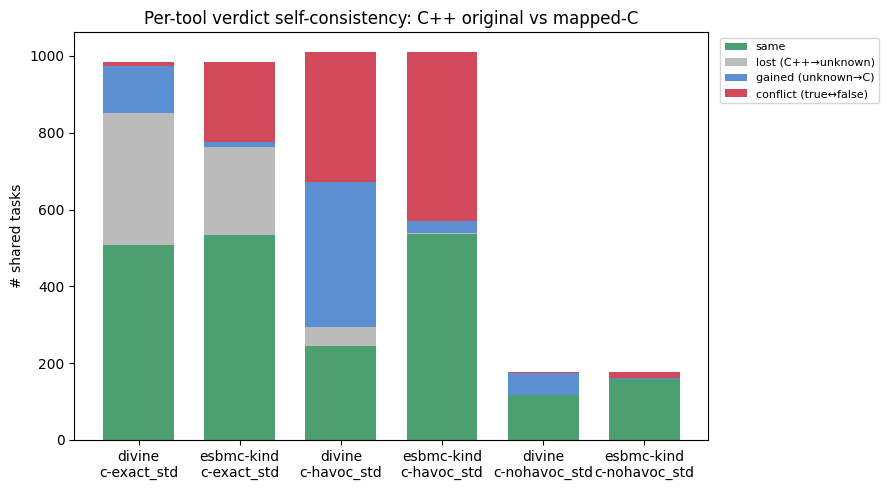

In [57]:
BUCKET_ORDER = ["same", "lost (C++→unknown)", "gained (unknown→C)", "conflict (true↔false)"]
BUCKET_COLORS = {"same": "#4C9F70", "lost (C++→unknown)": "#BBBBBB",
                 "gained (unknown→C)": "#5B8FD1", "conflict (true↔false)": "#D1495B"}

bdf = pd.DataFrame(buckets).T.reindex(columns=BUCKET_ORDER).fillna(0).astype(int)
labels = [f"{tool}\n{cfg}" for tool, cfg in bdf.index]

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(bdf))
for bk in BUCKET_ORDER:
    ax.bar(range(len(bdf)), bdf[bk], bottom=bottom, color=BUCKET_COLORS[bk], label=bk, width=0.7)
    bottom += bdf[bk].to_numpy()
ax.set_xticks(range(len(bdf)), labels)
ax.set_ylabel("# shared tasks")
ax.set_title("Per-tool verdict self-consistency: C++ original vs mapped-C")
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))
fig.tight_layout()
export_fig(fig, "rq2", "selfpair_buckets",
           "Per-tool agreement between a verifier's verdict on the C++ original and on its "
           "mapped-C version, over shared tasks: identical, lost to unknown, gained from "
           "unknown, or a true/false conflict.",
           label="fig:selfpair-buckets")


# RQ3 — Performance: CPU time & memory

Resource usage per task suite, treated separately for now (no cross-suite pairing yet).
CPU time is in seconds (timeouts land at ~900 s); memory is in GB. Note these are *all*
runs across the retained verifiers, so the distributions mix fast error-exits, real
solves, and timeouts — split by outcome later if needed.


In [58]:
res = df.assign(
    mem_gb=df.memory / 1e9,
    timeout=df.status.str.contains("TIMEOUT", na=False),
)

# Per-suite resource summary.
perf = (
    res.groupby("config", observed=True)
    .agg(
        runs=("cputime", "size"),
        timeouts=("timeout", "sum"),
        cpu_median_s=("cputime", "median"),
        cpu_p90_s=("cputime", lambda s: s.quantile(0.9)),
        cpu_max_s=("cputime", "max"),
        cpu_total_h=("cputime", lambda s: s.sum() / 3600),
        mem_median_gb=("mem_gb", "median"),
        mem_p90_gb=("mem_gb", lambda s: s.quantile(0.9)),
        mem_max_gb=("mem_gb", "max"),
    )
    .round(3)
)
display(export_table(perf, "rq3", "perf_summary",
                     "CPU time and memory per task suite (all retained verifiers, all "
                     "runs). Times in seconds, memory in GB.",
                     label="tab:perf-summary"))

# Per-verifier medians within each suite.
cpu_by_tool = res.pivot_table(index="tool", columns="config", values="cputime",
                              aggfunc="median", observed=False).round(2)
mem_by_tool = res.pivot_table(index="tool", columns="config", values="mem_gb",
                              aggfunc="median", observed=False).round(3)
print("Median CPU time (s) per verifier × suite:")
display(export_table(cpu_by_tool, "rq3", "cpu_median_by_tool",
                     "Median CPU time (s) per verifier and task suite.",
                     label="tab:cpu-median-by-tool"))
print("Median memory (GB) per verifier × suite:")
display(export_table(mem_by_tool, "rq3", "mem_median_by_tool",
                     "Median memory (GB) per verifier and task suite.",
                     label="tab:mem-median-by-tool"))


,runs,timeouts,cpu_median_s,cpu_p90_s,cpu_max_s,cpu_total_h,mem_median_gb,mem_p90_gb,mem_max_gb
config,,,,,,,,,
cpp-baseline,2194,21,5.371,28.017,902.072,13.253,0.202,0.495,15.0
c-exact_std,18677,1717,5.686,589.115,903.543,594.436,0.194,1.191,15.0
c-havoc_std,19209,1129,7.447,298.445,903.394,454.305,0.151,1.088,15.0
c-nohavoc_std,3382,115,2.471,61.726,902.664,49.394,0.117,0.604,15.0


Median CPU time (s) per verifier × suite:


config,cpp-baseline,c-exact_std,c-havoc_std,c-nohavoc_std
tool,,,,
2ls,NaN,0.18,0.12,0.12
bubaak,NaN,1.18,1.28,0.29
bubaak-split,NaN,2.86,2.03,0.98
cbmc,NaN,0.17,0.12,0.12
cpachecker,NaN,96.40,7.29,6.62
divine,17.35,2.37,16.84,3.21
emergentheta,NaN,5.14,11.83,3.10
esbmc-kind,1.50,10.79,0.39,0.38
mopsa,NaN,113.84,19.03,1.95


Median memory (GB) per verifier × suite:


config,cpp-baseline,c-exact_std,c-havoc_std,c-nohavoc_std
tool,,,,
2ls,NaN,0.009,0.005,0.005
bubaak,NaN,0.050,0.041,0.038
bubaak-split,NaN,0.072,0.061,0.058
cbmc,NaN,0.010,0.006,0.006
cpachecker,NaN,0.522,0.179,0.166
divine,0.368,0.078,0.568,0.170
emergentheta,NaN,0.193,0.469,0.127
esbmc-kind,0.114,0.112,0.048,0.047
mopsa,NaN,0.143,0.107,0.080


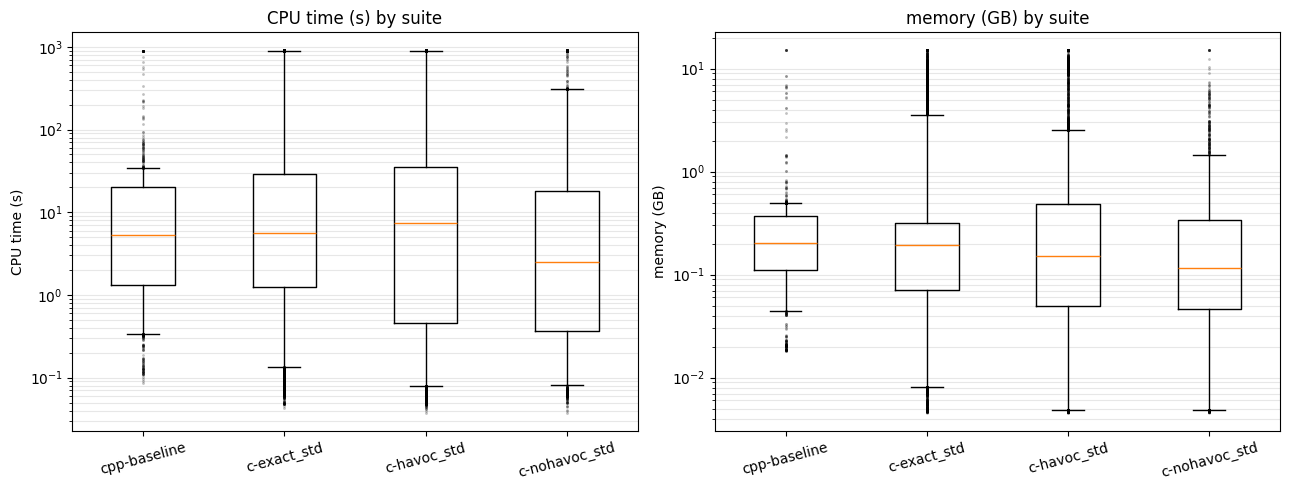

In [59]:
# Distributions per suite (log scale; whiskers at 5th/95th pct, dots are runs beyond).
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (col, lab) in zip(axes, [("cputime", "CPU time (s)"), ("mem_gb", "memory (GB)")]):
    data = [res.loc[res.config == c, col].dropna().to_numpy() for c in CONFIGS]
    ax.boxplot(data, tick_labels=CONFIGS, whis=(5, 95),
               flierprops=dict(marker=".", markersize=2, alpha=0.25))
    ax.set_yscale("log")
    ax.set_ylabel(lab)
    ax.set_title(f"{lab} by suite")
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", which="both", alpha=0.3)
fig.tight_layout()
export_fig(fig, "rq3", "resource_boxplots",
           "CPU time and memory distributions per task suite (log scale; whiskers at the "
           "5th/95th percentile).",
           label="fig:resource-box")


## Quantile (cactus) plots

BenchExec-style: per verifier, take its **correctly solved** tasks (`bx_category ==
"correct"`), sort their CPU times ascending, and plot `x = # solved`, `y = CPU time`
(log). A curve further right solves more tasks; lower means faster. One plot per suite
below, then one over the C/C++ **shared** tasks where the native-C++ verifiers appear
twice — once on the C++ input (dashed), once on the mapped-C input (solid, same colour).


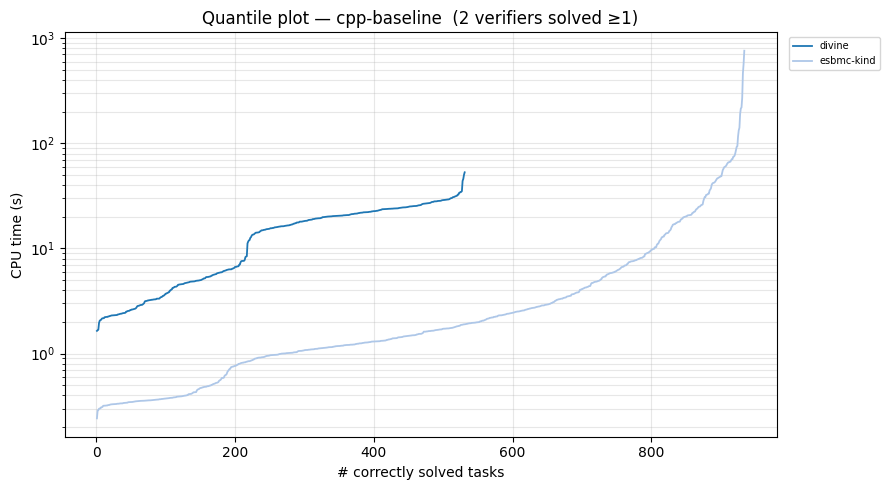

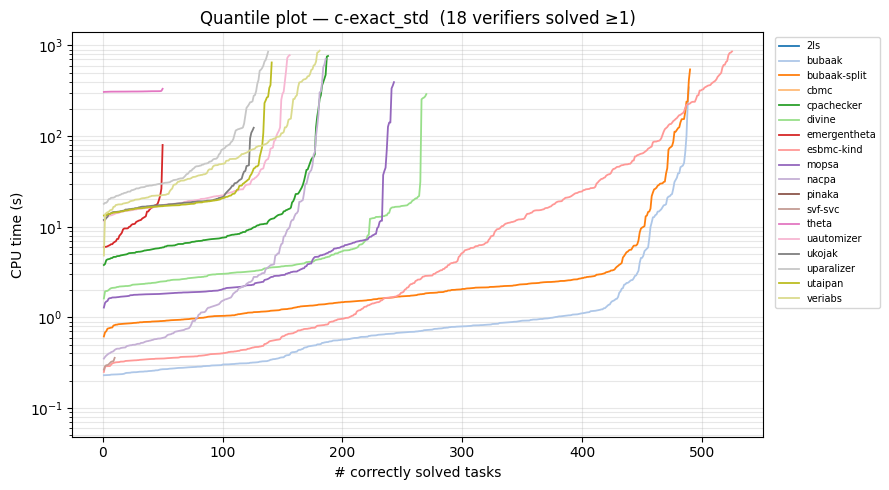

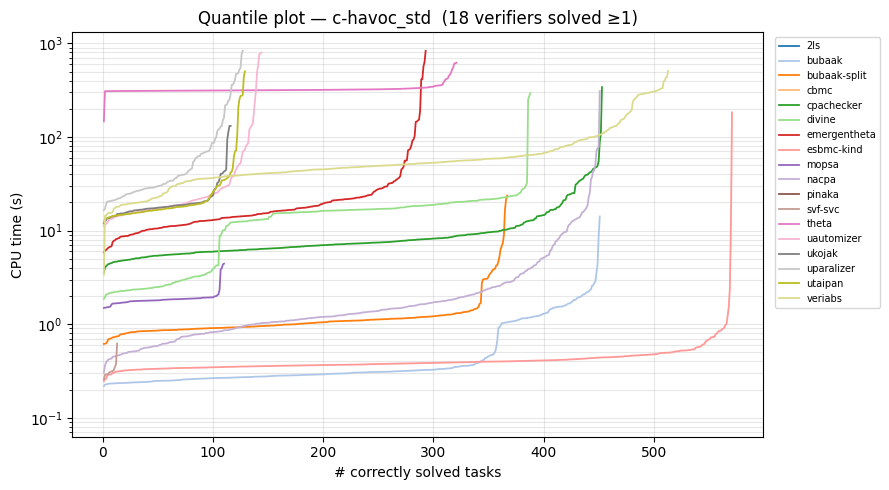

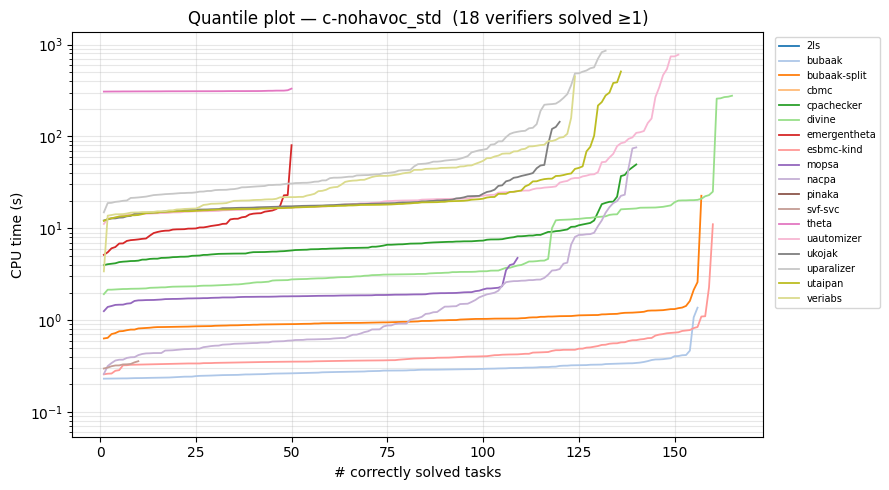

In [60]:
def solved_times(d: pd.DataFrame) -> np.ndarray:
    """Sorted CPU times of correctly-solved runs (BenchExec 'correct')."""
    return d.loc[d.bx_category == "correct", "cputime"].dropna().sort_values().to_numpy()


def quantile_plot(series: dict, ax, title: str):
    """series: label -> sorted cpu-time array. Native-C++ curves ('… (C++)') are dashed
    and share the colour of their mapped-C namesake."""
    bases = list(dict.fromkeys(lbl.replace(" (C++)", "") for lbl in series))
    cmap = plt.get_cmap("tab20")
    color = {b: cmap(i % 20) for i, b in enumerate(bases)}
    for lbl, arr in series.items():
        if len(arr) == 0:
            continue
        ax.plot(range(1, len(arr) + 1), arr, label=lbl,
                color=color[lbl.replace(" (C++)", "")], lw=1.3,
                ls="--" if lbl.endswith("(C++)") else "-")
    ax.set_yscale("log")
    ax.set_xlabel("# correctly solved tasks")
    ax.set_ylabel("CPU time (s)")
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=7, ncol=1, loc="upper left", bbox_to_anchor=(1.01, 1.0))


for cfg in CONFIGS:
    sub = df[df.config == cfg]
    series = {t: solved_times(sub[sub.tool == t]) for t in sorted(sub.tool.unique())}
    series = {k: v for k, v in series.items() if len(v)}
    fig, ax = plt.subplots(figsize=(9, 5))
    quantile_plot(series, ax, f"Quantile plot — {cfg}  ({len(series)} verifiers solved ≥1)")
    fig.tight_layout()
    export_fig(fig, "rq3", f"quantile_{cfg}",
               f"Quantile (cactus) plot of CPU time for correctly solved tasks on "
               f"\\texttt{{{cfg}}}; one curve per verifier.",
               label=f"fig:quantile-{cfg}")


### Shared C/C++ tasks — all verifiers, native-C++ ones doubled

One plot per mapped suite, restricted to tasks present in **both** that suite and the
C++ original. Every mapped-C verifier contributes one (solid) curve; the native-C++
verifiers (`divine`, `esbmc-kind`; `cbmc` excluded from the C++ side) contribute a
second, dashed curve from their C++ run, so the mapping cost is visible as the gap
between a tool's solid and dashed lines.


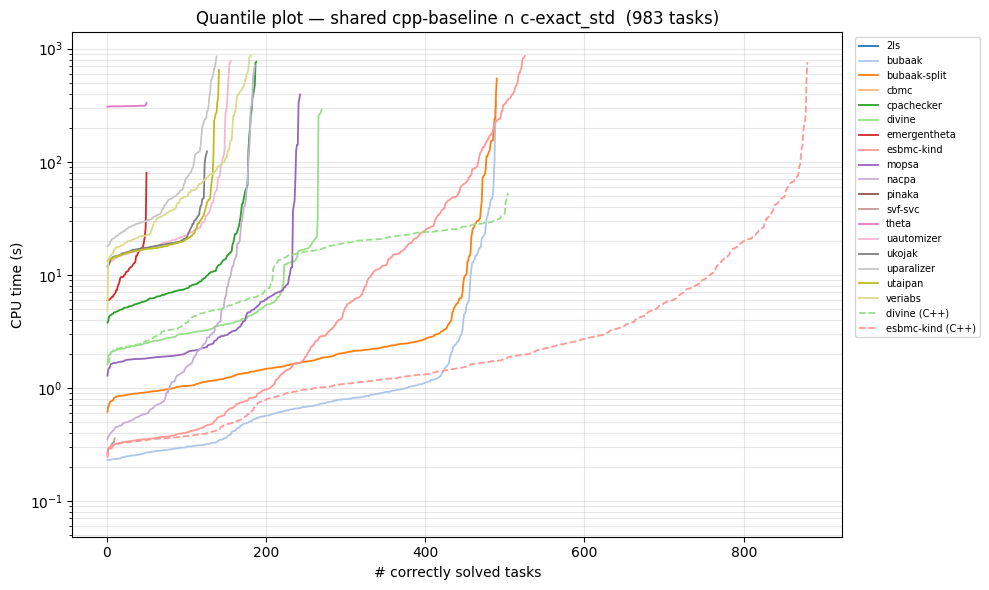

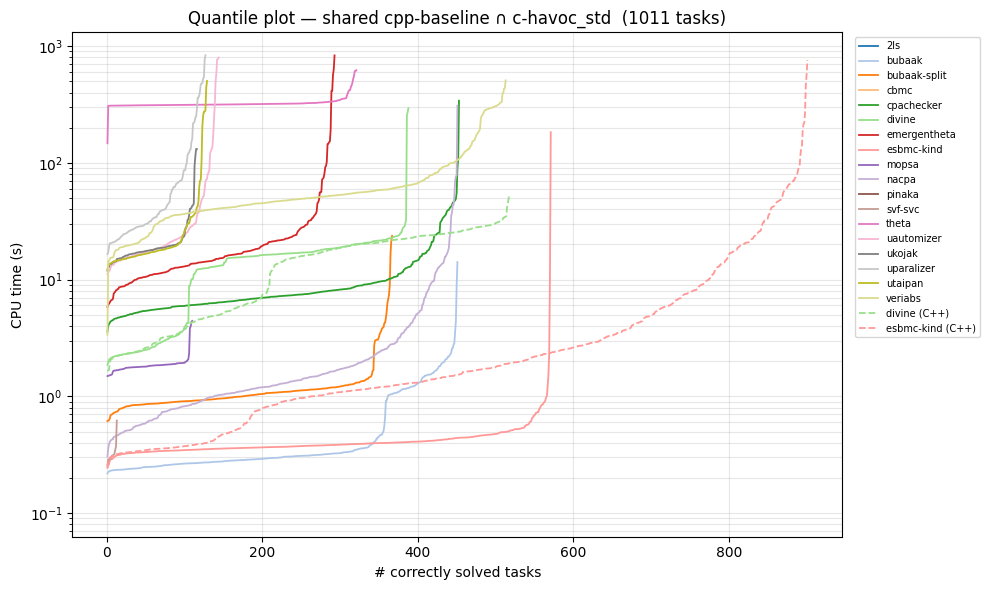

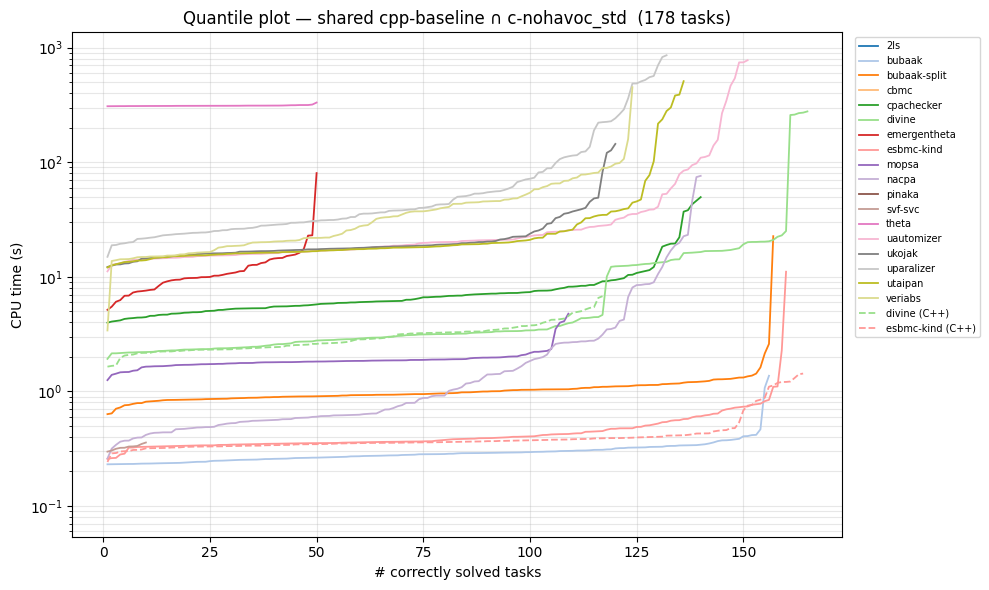

In [61]:
def shared_quantile(c_cfg: str, cpp_cfg: str = CPP_REF):
    """Cactus plot over the tasks shared by cpp_cfg and c_cfg; native-C++ tools doubled."""
    shared = set(df.loc[df.config == cpp_cfg, "task"]) & set(df.loc[df.config == c_cfg, "task"])
    series = {}
    csub = df[(df.config == c_cfg) & (df.task.isin(shared))]
    for t in sorted(csub.tool.unique()):
        series[t] = solved_times(csub[csub.tool == t])             # mapped-C run (solid)
    psub = df[(df.config == cpp_cfg) & (df.task.isin(shared))]
    for t in sorted(psub.tool.unique()):
        series[f"{t} (C++)"] = solved_times(psub[psub.tool == t])  # C++ run (dashed)
    series = {k: v for k, v in series.items() if len(v)}

    fig, ax = plt.subplots(figsize=(10, 6))
    quantile_plot(series, ax, f"Quantile plot — shared {cpp_cfg} ∩ {c_cfg}  ({len(shared)} tasks)")
    fig.tight_layout()
    export_fig(fig, "rq3", f"quantile_shared_{c_cfg}",
               f"Quantile (cactus) plot over the {len(shared)} tasks shared by the C++ "
               f"suite \\texttt{{{cpp_cfg}}} and \\texttt{{{c_cfg}}}. Native-C++ verifiers "
               f"appear twice: dashed = C++ input, solid = mapped-C input (same colour).",
               label=f"fig:quantile-shared-{c_cfg}")


# One shared-task cactus per mapped suite (rename-proof: no suite name hardcoded).
for c_cfg in MAPPED_CONFIGS:
    shared_quantile(c_cfg)


In [62]:
# --- Why does divine's cactus curve never approach the time limit? ---
# A quantile (cactus) curve only plots *correctly solved* tasks. If a tool's correct
# solves are all fast, and it only ever runs long on tasks it ultimately fails (timeout /
# unknown), then its curve tops out well below the limit even though the tool does spend
# the full budget on hard tasks. Compare divine against esbmc-kind on one C++ suite and
# one mapped suite (cbmc was dropped from the C++ side, so it is not comparable here).
DIAG_TOOLS = ["divine", "esbmc-kind"]
DIAG_CFGS = [CPP_REF, "c-exact_std"]            # C++ original + the exact_std mapped suite

diag_rows = []
for cfg in DIAG_CFGS:
    for tool in DIAG_TOOLS:
        d = df[(df.tool == tool) & (df.config == cfg)]
        solved = d.loc[d.bx_category == "correct", "cputime"].dropna()     # correct solves
        other = d.loc[d.bx_category != "correct", "cputime"].dropna()      # timeout/unknown/wrong
        diag_rows.append({
            "config": cfg, "tool": tool, "runs": len(d), "correct": len(solved),
            "solve_cpu_med": round(solved.median(), 1) if len(solved) else np.nan,
            "solve_cpu_p90": round(solved.quantile(0.9), 1) if len(solved) else np.nan,
            "solve_cpu_max": round(solved.max(), 1) if len(solved) else np.nan,   # rightmost cactus point
            "nonsolve_cpu_max": round(other.max(), 1) if len(other) else np.nan,  # how long it runs when failing
            "timeouts": int(d.status.str.contains("TIMEOUT", na=False).sum()),
        })
diag = pd.DataFrame(diag_rows).set_index(["config", "tool"])
display(diag)

for cfg in DIAG_CFGS:
    g = diag.loc[cfg]
    print(f"{cfg}: divine's slowest *correct* solve = {g.loc['divine', 'solve_cpu_max']:.0f}s, "
          f"slowest run overall = {g.loc['divine', 'nonsolve_cpu_max']:.0f}s "
          f"({g.loc['divine', 'timeouts']:.0f} timeouts). "
          f"esbmc-kind's slowest correct solve = {g.loc['esbmc-kind', 'solve_cpu_max']:.0f}s.")

print("\nTakeaway: divine's *correct* solves are all comparatively fast, so its cactus curve "
      "tops out far below the time limit — this is genuine tool behaviour, not a plotting "
      "artefact. divine (explicit-state model checking) does not gradually grind out harder "
      "verdicts as the budget grows: on the C++ suite it runs the full budget only on tasks "
      "it then *fails* (timeouts -> unknown), and on the mapped suite it does not even consume "
      "the budget (0 timeouts, longest run well under the limit) — it bails to unknown early. "
      "Either way it almost never returns a correct verdict at high CPU. esbmc-kind "
      "(BMC / k-induction) instead keeps returning correct verdicts right up to the limit, so "
      "its curve climbs to the top of the plot.")

# What does divine actually return in its non-solve cases? Mostly a fast `unknown`, NOT a
# timeout: divine gives up early (its svc wrapper prints only `result: unknown`, no reason)
# rather than exhausting the CPU budget. Timeouts are rare except on the havoc suite, where
# the over-approximated nondeterminism blows up the state space.
print("\ndivine status x category per suite (terminationreason 'cputime' == real timeout):")
dv = df[df.tool == "divine"]
display(dv.pivot_table(index="config", columns="status", values="task",
                       aggfunc="count", observed=True, fill_value=0))
display(dv.groupby(["config", "termination"], observed=True).size()
          .rename("runs").reset_index())

runs  correct  solve_cpu_med  solve_cpu_p90  \
config       tool                                                      
cpp-baseline divine      1097      531           16.2           26.9   
             esbmc-kind  1097      934            1.5           18.0   
c-exact_std  divine       983      270            3.5           16.4   
             esbmc-kind   983      525            2.6          134.2   

                         solve_cpu_max  nonsolve_cpu_max  timeouts  
config       tool                                                   
cpp-baseline divine               53.0             902.1         3  
             esbmc-kind          760.1             901.0        18  
c-exact_std  divine              290.7             902.0         1  
             esbmc-kind          859.3             901.3       234

cpp-baseline: divine's slowest *correct* solve = 53s, slowest run overall = 902s (3 timeouts). esbmc-kind's slowest correct solve = 760s.
c-exact_std: divine's slowest *correct* solve = 291s, slowest run overall = 902s (1 timeouts). esbmc-kind's slowest correct solve = 859s.

Takeaway: divine's *correct* solves are all comparatively fast, so its cactus curve tops out far below the time limit — this is genuine tool behaviour, not a plotting artefact. divine (explicit-state model checking) does not gradually grind out harder verdicts as the budget grows: on the C++ suite it runs the full budget only on tasks it then *fails* (timeouts -> unknown), and on the mapped suite it does not even consume the budget (0 timeouts, longest run well under the limit) — it bails to unknown early. Either way it almost never returns a correct verdict at high CPU. esbmc-kind (BMC / k-induction) instead keeps returning correct verdicts right up to the limit, so its curve climbs to the top of the plot.

divin

status,TIMEOUT,false(unreach-call),true,unknown
config,,,,
cpp-baseline,3,0,549,545
c-exact_std,1,118,174,690
c-havoc_std,86,601,258,66
c-nohavoc_std,0,55,120,3


,config,termination,runs
0,cpp-baseline,cputime,3
1,c-exact_std,cputime,1
2,c-havoc_std,cputime,86


In [63]:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        # --- Regenerate figures/README.md (the paper-facing manifest) from MANIFEST ---
# Built from the exact artifacts this run exported, so it never drifts from the suite
# names / files actually produced. Run this cell last (after every export above).
RQ_TITLES = {
    "rq2": "RQ2 — Soundness / verdict agreement",
    "rq3": "RQ3 — Performance / CPU time & memory",
}

# Task-set descriptions for the manifest header (kept in sync with the notebook intro).
TASK_SETS_MD = """\
## Task sets (configs)

One original C++ suite and three mapped-C suites that differ in how cir2c handles the C++
standard library. By task name they nest:
`c-nohavoc_std` ⊆ `c-exact_std` ⊆ `c-havoc_std` ⊆ `cpp-baseline`.

- **`cpp-baseline`** — the original C++ tasks, run only by the natively-C++ verifiers.
  Filtered to tasks that actually contain an assertion: the property is assertion failure
  (`reach_error` reachability), so a task with no assert is meaningless for it, and those
  assert-free tasks were also the main source of mislabeling, so they were dropped.
- **`c-exact_std`** — cir2c output with the std library mapped *accurately* (no
  over-approximation). May still contain unlinked `extern` functions (some missing
  definitions).
- **`c-nohavoc_std`** — same as `c-exact_std`, but tasks that still have undefined `extern`
  functions are filtered out (every called function has a definition).
- **`c-havoc_std`** — std library functions (and other unmodelled calls) are *havoc'd*: they
  may return anything. An over-approximation, which shows up in the results (e.g. spurious
  property violations / wrong verdicts). It is the largest mapped set because havoc'ing maps
  tasks an accurate std mapping cannot.

Suite names are discovered at runtime, so renames flow through automatically."""


def _md_caption(cap: str) -> str:
    """Light LaTeX->markdown cleanup so captions read well in the manifest."""
    cap = re.sub(r"\\texttt\{([^}]*)\}", r"`\1`", cap)
    cap = re.sub(r"\\emph\{([^}]*)\}", r"*\1*", cap)
    cap = cap.replace("\\&", "&").replace("\\_", "_")
    cap = cap.replace(".\\ ", ". ").replace(",\\ ", ", ").replace("\\ ", " ")
    return cap.strip()


def write_manifest(path: Path = FIG_ROOT / "README.md") -> None:
    # Dedupe by (rq, kind, name), keeping the last export of each.
    seen = {(e["rq"], e["kind"], e["name"]): e for e in MANIFEST}
    lines = [
        "# Figures & tables manifest",
        "",
        "Auto-generated by the last cell of [`analysis.ipynb`](../analysis.ipynb) from the "
        "artifacts it exports, grouped by research question. Each entry pairs the file(s) "
        "with its `\\label` and the caption used in the notebook. "
        "`\\input{<rq>/<name>.tex}` to drop a figure/table into the paper. Figure `.tex` bake "
        "in their `\\includegraphics` path (`figures/results/rq23/<rq>/...`), so copy this "
        "`figures/` folder to `<paper>/figures/results/rq23/`. Figures also "
        "have a companion `.pdf`; tables are `.tex` only. Re-running the notebook regenerates "
        "everything, including this file. **Do not edit by hand.**",
        "",
        TASK_SETS_MD,
        "",
    ]
    for rq in sorted({e["rq"] for e in seen.values()}):
        lines.append(f"## {RQ_TITLES.get(rq, rq.upper())} (`{rq}/`)")
        lines.append("")
        for kind, header, file_fmt in [
            ("figure", "### Figures", "`{name}.{{tex,pdf}}`"),
            ("table", "### Tables", "`{name}.tex`"),
        ]:
            rows = sorted((e for e in seen.values() if e["rq"] == rq and e["kind"] == kind),
                          key=lambda e: e["name"])
            if not rows:
                continue
            lines += [header, "", "| file | label | description |",
                      "|------|-------|-------------|"]
            for e in rows:
                lines.append(f"| {file_fmt.format(name=e['name'])} | `{e['label']}` | "
                             f"{_md_caption(e['caption'])} |")
            lines.append("")
    path.write_text("\n".join(lines).rstrip() + "\n", encoding="utf-8")
    print(f"Wrote {path} — {len(seen)} artifacts "
          f"({sum(e['kind'] == 'figure' for e in seen.values())} figures, "
          f"{sum(e['kind'] == 'table' for e in seen.values())} tables).")


write_manifest()

Wrote figures/README.md — 41 artifacts (16 figures, 25 tables).
